<a href="https://colab.research.google.com/github/parthmavani/CodeAlpha_CarPricePrediction/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")


In [3]:
df = pd.read_csv("car_data.csv")

print(df.head())


  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [4]:
# removing extra spaces
df.columns = df.columns.str.strip()

print("\nColumn Names:\n")
print(df.columns)

# checking null values
print("\nMissing Values:\n")
print(df.isnull().sum())

# removing missing values
df = df.dropna()

print("\nDataset Shape:", df.shape)


Column Names:

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Missing Values:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Dataset Shape: (301, 9)


In [5]:
print("\nDataset Information:\n")

print(df.info())

print("\nStatistical Summary:\n")

print(df.describe())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Statistical Summary:

              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.2

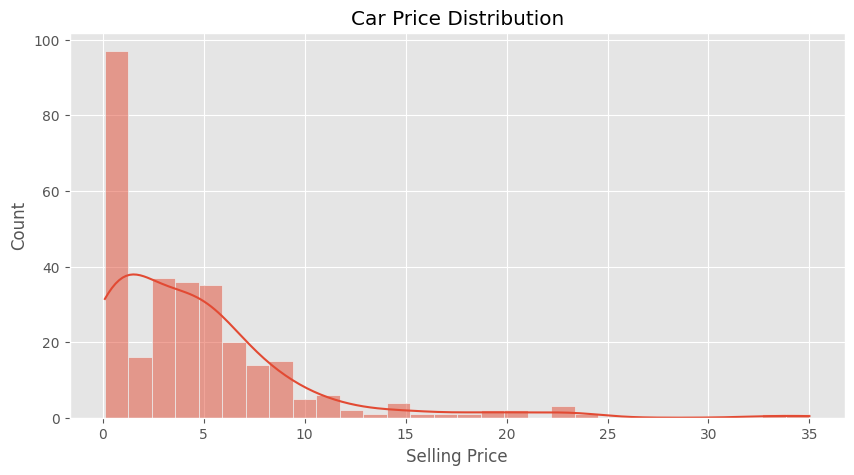


Observation:
Most cars are concentrated in lower and medium price ranges.


In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df['Selling_Price'], bins=30, kde=True)

plt.title("Car Price Distribution")

plt.xlabel("Selling Price")

plt.show()

print("\nObservation:")
print("Most cars are concentrated in lower and medium price ranges.")



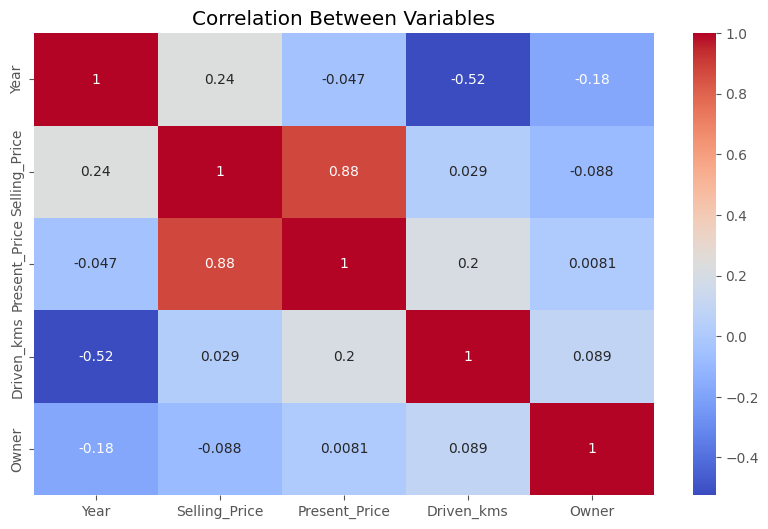

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Variables")

plt.show()

In [8]:
current_year = 2025

df['Car_Age'] = current_year - df['Year']

# removing unnecessary column
df.drop('Year', axis=1, inplace=True)

print(df.head())

  Car_Name  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0     ritz           3.35           5.59       27000    Petrol       Dealer   
1      sx4           4.75           9.54       43000    Diesel       Dealer   
2     ciaz           7.25           9.85        6900    Petrol       Dealer   
3  wagon r           2.85           4.15        5200    Petrol       Dealer   
4    swift           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       11  
1       Manual      0       12  
2       Manual      0        8  
3       Manual      0       14  
4       Manual      0       11  


In [9]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("\nEncoded Dataset:\n")

print(df.head())


Encoded Dataset:

   Car_Name  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0        90           3.35           5.59       27000          2   
1        93           4.75           9.54       43000          1   
2        68           7.25           9.85        6900          2   
3        96           2.85           4.15        5200          2   
4        92           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  Car_Age  
0             0             1      0       11  
1             0             1      0       12  
2             0             1      0        8  
3             0             1      0       14  
4             0             1      0       11  


In [10]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


In [13]:
y_pred = model.predict(X_test)

print("\nPredicted Prices:\n")

print(y_pred[:10])



Predicted Prices:

[ 0.4443 10.3488  4.972   0.2159  7.9384  6.698   1.134   0.606   0.4667
  6.602 ]


In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation\n")

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)



Model Evaluation

Mean Absolute Error: 0.6021950819672133
Mean Squared Error: 0.7969036719672131
Root Mean Squared Error: 0.8926946129372648
R2 Score: 0.9654055371911539


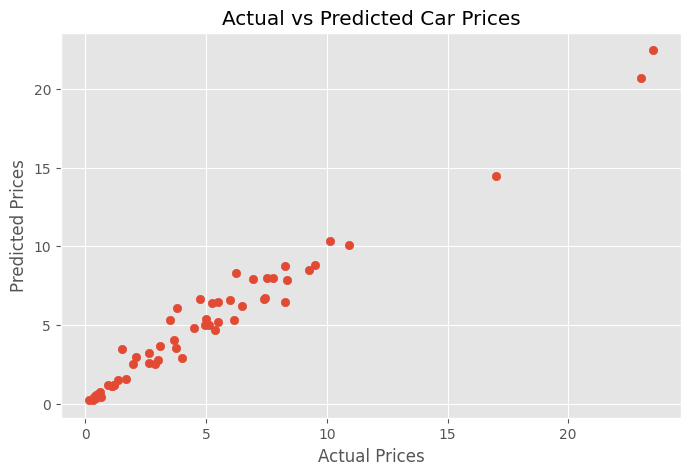

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Car Prices")

plt.show()

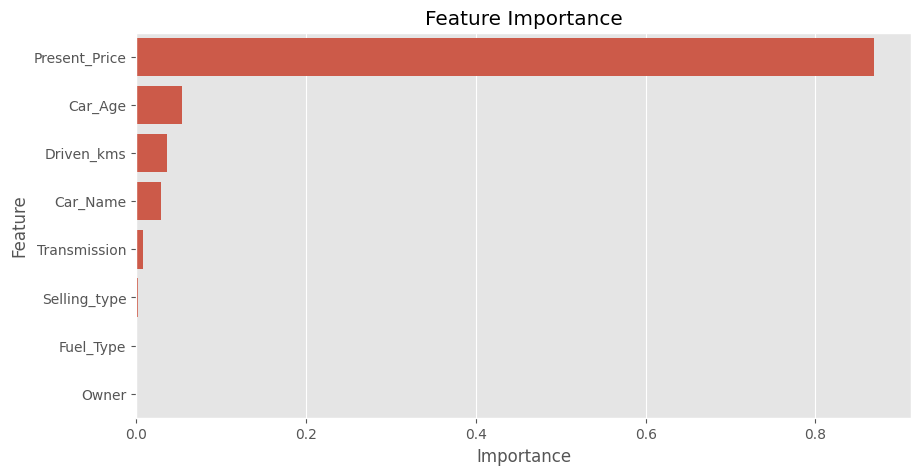

In [16]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()


In [17]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("\nSample Predicted Price:", prediction[0])


Sample Predicted Price: 3.923500000000003


In [18]:
print("""

==============================
Key Insights
==============================

1. Car age significantly affects selling price.

2. Newer cars generally have higher market value.

3. Fuel type and transmission also influence pricing.

4. Random Forest Regression performed well for prediction.

5. Multiple car features together help estimate market price accurately.

""")



Key Insights

1. Car age significantly affects selling price.

2. Newer cars generally have higher market value.

3. Fuel type and transmission also influence pricing.

4. Random Forest Regression performed well for prediction.

5. Multiple car features together help estimate market price accurately.




In [19]:
print("""

==============================
Conclusion
==============================

This project used machine learning techniques to predict car prices
based on multiple vehicle features.

The workflow included:
- data cleaning
- feature engineering
- visualization
- regression modeling
- model evaluation

The Random Forest Regression model achieved good prediction accuracy
and demonstrated how machine learning can solve real-world pricing problems.

""")



Conclusion

This project used machine learning techniques to predict car prices
based on multiple vehicle features.

The workflow included:
- data cleaning
- feature engineering
- visualization
- regression modeling
- model evaluation

The Random Forest Regression model achieved good prediction accuracy
and demonstrated how machine learning can solve real-world pricing problems.


